# Entrega 01 – Coleta, Limpeza e Integração dos Dados

**PI Ciência de Dados – Projeto Interdisciplinar 4º semestre CCOMP – FECAP / CTI Global**

Professor: Eduardo Savino Gomes

Integrantes: Bruno Nobrega, Kaio Inglez, Mauricio Suster e Yuri Santana

Etapas deste notebook: (1) identificação da fonte, (2) coleta, (3) descrição e exploração, (4) seleção, (5) limpeza e uniformização, (6) integração, (7) derivação de variáveis e (8) formatação e gravação da base final.

In [1]:
import os, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Identificação da fonte de dados

| Item | Descrição |
|---|---|
| Fonte | CTI Global (empresa parceira) |
| Arquivo | `Demonstrativo Fecap v3.csv`, enviado dentro de `DADOS_FECAP.zip` |
| Formato | CSV sem cabeçalho, separador `;`, decimal `,`, codificação ISO-8859-1 (latin1) |
| Tamanho | 75 MB (9 MB compactado) |
| Conteúdo | Balanço (BAL), DRE e Fluxo de Caixa (FLU) de uma empresa concessionária |
| Período | 12 anos (Ano 1 a Ano 12), sem datas de calendário |
| Granularidade | uma linha por conta × ano × cenário (1.200 cenários simulados) |
| Unidade | R\$ (reais nominais) |
| Condições de uso | Dados simulados, sem dados pessoais; uso restrito ao projeto |

Não usamos fontes externas nesta entrega: como o arquivo não tem datas de calendário, não dá para cruzar com índices como IPCA ou Selic de forma confiável.

## 2. Coleta dos dados (camada *raw*)

No Colab, a célula abaixo pede o upload do `DADOS_FECAP.zip`. O arquivo original é lido como texto e **não é alterado**: essa é a camada *raw*.

In [2]:
if not os.path.exists('Demonstrativo Fecap v3.csv'):
    from google.colab import files      # só funciona no Colab
    enviados = files.upload()           # enviar o DADOS_FECAP.zip (ou o próprio CSV)
    for nome in enviados:               # funciona mesmo se o arquivo vier como 'DADOS_FECAP (1).zip'
        if nome.lower().endswith('.zip'):
            zipfile.ZipFile(nome).extractall()

raw = pd.read_csv('Demonstrativo Fecap v3.csv', sep=';', encoding='latin1', header=None,
                  names=['ano', 'cenario', 'conta', 'valor'], dtype=str)
print('Linhas:', len(raw), '| Colunas:', raw.shape[1])
raw.head(8)

Linhas: 1002000 | Colunas: 4


,ano,cenario,conta,valor
0,Ano 1,Total Cen_00001,NaN,"0,025138815"
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,"10.631.127.075,2579"
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,"1.795.720.872,17537"
3,Ano 1,Total Cen_00001,BAL - Disponível,"1.205.264.965,51818"
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,"95.680.421,9232409"
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,"584.661,46688296"
6,Ano 1,Total Cen_00001,BAL - Contas a Receber - Clientes,"453.870.957,151068"
7,Ano 1,Total Cen_00001,BAL - Estoques Diversos,"86.620,78872148"


## 3. Descrição e exploração inicial

In [3]:
print('Anos:', raw['ano'].unique())
print('Cenários:', raw['cenario'].nunique(), '(de', raw['cenario'].iloc[0], 'a', raw['cenario'].iloc[-1], ')')
print('Contas distintas:', raw['conta'].nunique())
print('Linhas sem nome de conta:', raw['conta'].isna().sum())
print('Valores vazios:', raw['valor'].isna().sum())

# quantas contas cada bloco tem
blocos = raw['conta'].dropna().str[:3].value_counts()
print('\nLinhas por bloco:'); print(blocos)

Anos: <StringArray>
[ 'Ano 1',  'Ano 2',  'Ano 3',  'Ano 4',  'Ano 5',  'Ano 6',  'Ano 7',
  'Ano 8',  'Ano 9', 'Ano 10', 'Ano 11', 'Ano 12']
Length: 12, dtype: str
Cenários: 1200 (de Total Cen_00001 a Total Cen_01200 )
Contas distintas: 69
Linhas sem nome de conta: 43200
Valores vazios: 0



Linhas por bloco:
conta
BAL    584400
DRE    201600
FLU    172800
Name: count, dtype: int64


In [4]:
# nem todo ano tem a mesma quantidade de linhas
linhas_por_ano = raw.groupby('ano').size() / raw['cenario'].nunique()
print('Linhas por cenário em cada ano:')
print(linhas_por_ano.astype(int).sort_index(key=lambda s: s.str.replace('Ano ', '').astype(int)))

Linhas por cenário em cada ano:
ano
Ano 1     71
Ano 2     71
Ano 3     72
Ano 4     72
Ano 5     72
Ano 6     72
Ano 7     72
Ano 8     72
Ano 9     72
Ano 10    72
Ano 11    72
Ano 12    45
dtype: int64


In [5]:
# exemplo: contas do Ano 3, cenário 1
exemplo = raw[(raw['ano'] == 'Ano 3') & (raw['cenario'] == 'Total Cen_00001')]
exemplo[['conta', 'valor']].head(20)

,conta,valor
170400,NaN,"0,025043663"
170401,BAL - Total do Ativo,"10.812.725.089,2948"
170402,BAL - Ativo Circulante,"2.292.583.955,8277"
170403,BAL - Disponível,"1.748.421.038,97609"
170404,BAL - Contas a Receber - SWAP,"224.856.873,567424"
170405,BAL - Contas a Receber - Partes Relacionadas,"584.661,46688296"
170406,BAL - Contas a Receber - Clientes,"405.567.948,895069"
170407,BAL - Estoques Diversos,"86.620,78872148"
170408,BAL - Outros Créditos,"-86.933.187,8664957"
170409,BAL - Realizável a Longo Prazo,"1.207.936.261,35958"


O que vimos na exploração:
- Cada cenário/ano tem 72 linhas, menos os Anos 1 e 2 (71 linhas: não existe a conta *BAL - Dividendos Antecipados*) e o Ano 12 (45 linhas: é o balanço de encerramento da concessão, sem Patrimônio Líquido).
- Em cada bloco de 72 linhas há 3 linhas sem nome de conta: a primeira é um "check" do balanço (Ativo + Passivo ≈ 0) e as outras duas são separadores com valor 0.
- Os valores estão no formato brasileiro (`1.234.567,89`) e as despesas e passivos aparecem com sinal negativo.

## 4. Seleção dos dados

Das 69 contas, selecionamos as que serão usadas nas análises, nos KPIs e no dashboard.

In [6]:
selecao = {
    # DRE
    'DRE - Receita': 'receita',
    'DRE - Tributos': 'tributos',
    'DRE - Custos': 'custos',
    'DRE - Depreciação e Amortização': 'depreciacao_amortizacao',
    'DRE - Resultado Operacional': 'resultado_operacional',
    'DRE - Outros Resultados Operacionais': 'outros_resultados',
    'DRE - Resultado Financeiro': 'resultado_financeiro',
    'DRE - Imposto de Renda e Contribuição Social': 'ir_cs',
    'DRE - Resultado Líquido': 'lucro_liquido',
    'DRE - EBITDA': 'ebitda_reportado',
    # Balanço
    'BAL - Disponível': 'caixa',
    'BAL - Ativo Circulante': 'ativo_circulante',
    'BAL - Total do Ativo': 'ativo_total',
    'BAL - Empréstimos': 'emprestimos_cp',
    'BAL - Emprést': 'emprestimos_lp',
    'BAL - Patrimônio Líquido': 'patrimonio_liquido',
    # Fluxo de caixa
    'FLU - Investimentos': 'investimentos',
    'FLU - Distribuição para Acionista': 'dividendos',
    'FLU - Geração de Caixa': 'geracao_caixa',
    'FLU - Saldo Final': 'saldo_final_caixa',
}
print(len(selecao), 'contas selecionadas')

20 contas selecionadas


## 5. Limpeza e uniformização (camada *staging*)

In [7]:
stg = raw.copy()

# 5.1 remover linhas sem nome de conta (check e separadores)
antes = len(stg)
stg = stg.dropna(subset=['conta'])
print('Linhas removidas (sem conta):', antes - len(stg))

# 5.2 padronizar os nomes das contas: algumas têm espaço duplo ou espaço no fim (ex.: 'BAL  - Patrimônio Líquido')
nomes_antes = stg['conta'].unique()
stg['conta'] = stg['conta'].str.replace(r'\s+', ' ', regex=True).str.strip()
print('Nomes de conta corrigidos:', sum(n != ' '.join(n.split()) for n in nomes_antes))

# 5.3 converter o valor do formato brasileiro para número
stg['valor'] = stg['valor'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# 5.4 ano e cenário como números inteiros
stg['ano'] = stg['ano'].str.replace('Ano ', '').astype(int)
stg['cenario'] = stg['cenario'].str.replace('Total Cen_', '').astype(int)

# 5.5 verificações
print('Valores nulos depois da conversão:', stg['valor'].isna().sum())
print('Linhas duplicadas (cenario, ano, conta):', stg.duplicated(['cenario', 'ano', 'conta']).sum())
print('Contas selecionadas que não foram encontradas:', set(selecao) - set(stg['conta']))
stg.dtypes

Linhas removidas (sem conta): 43200


Nomes de conta corrigidos: 9


Valores nulos depois da conversão: 0
Linhas duplicadas (cenario, ano, conta): 0


Contas selecionadas que não foram encontradas: set()


ano          int64
cenario      int64
conta          str
valor      float64
dtype: object

## 6. Integração dos demonstrativos

Os três demonstrativos (Balanço, DRE e Fluxo de Caixa) estão empilhados no mesmo arquivo. Para integrar, transformamos as contas em colunas: a base fica com **uma linha por cenário e ano**. Depois conferimos se os demonstrativos batem entre si.

In [8]:
base = stg[stg['conta'].isin(selecao)].pivot_table(index=['cenario', 'ano'], columns='conta', values='valor')
base = base.rename(columns=selecao)[list(selecao.values())].reset_index()
print('Base integrada:', base.shape)

# conferência 1: o saldo final do fluxo de caixa é igual ao caixa do balanço?
dif = (base['saldo_final_caixa'] - base['caixa']).abs().max()
print('Maior diferença entre FLU Saldo Final e BAL Disponível: R$', round(dif, 4))

# conferência 2: o balanço fecha (Ativo + Passivo = 0)? usamos o total do passivo só para conferir
chk = stg[stg['conta'].isin(['BAL - Total do Ativo', 'BAL - Total do Passivo'])].groupby(['cenario', 'ano'])['valor'].sum()
print('Maior diferença Ativo + Passivo: R$', round(chk.abs().max(), 4))

Base integrada: (14400, 22)
Maior diferença entre FLU Saldo Final e BAL Disponível: R$ 0.0
Maior diferença Ativo + Passivo: R$ 0.0252


## 7. Derivação de variáveis

Criamos variáveis novas a partir das contas selecionadas. Antes, deixamos despesas e passivos com **sinal positivo** (no arquivo eles são negativos).

In [9]:
positivos = ['tributos', 'custos', 'depreciacao_amortizacao', 'ir_cs', 'patrimonio_liquido', 'investimentos', 'dividendos']
base[positivos] = base[positivos] * -1

# dívida: a linha de empréstimos de curto prazo fica positiva a partir do Ano 4
# (o modelo acumula ali as amortizações), então a dívida é a soma das duas linhas com o sinal trocado
# no Ano 12 a linha de empréstimos de longo prazo não existe (dívida já quitada) -> tratamos como zero
base[['emprestimos_cp', 'emprestimos_lp']] = base[['emprestimos_cp', 'emprestimos_lp']].fillna(0)
base['divida_bruta'] = -(base['emprestimos_cp'] + base['emprestimos_lp'])
base['divida_liquida'] = base['divida_bruta'] - base['caixa']

base['receita_liquida'] = base['receita'] - base['tributos']
base['ebitda'] = base['resultado_operacional'] + base['outros_resultados'] + base['depreciacao_amortizacao']
base['margem_ebitda'] = base['ebitda'] / base['receita_liquida']
base['margem_liquida'] = base['lucro_liquido'] / base['receita_liquida']
base['custos_sobre_receita'] = base['custos'] / base['receita_liquida']
base['grupo_cenario'] = np.where(base['cenario'] <= 1000, 'Cenários 1-1000', 'Cenários 1001-1200')

print('Diferença média EBITDA reportado - EBITDA calculado (R$ mi):',
      round((base['ebitda_reportado'] - base['ebitda']).mean() / 1e6, 1))
base[['cenario', 'ano', 'receita_liquida', 'ebitda', 'margem_ebitda', 'margem_liquida', 'divida_bruta']].head()

Diferença média EBITDA reportado - EBITDA calculado (R$ mi): 300.8


conta,cenario,ano,receita_liquida,ebitda,margem_ebitda,margem_liquida,divida_bruta
0,1,1,6.251265e+09,4.929185e+09,0.788510,0.390840,5.928359e+09
1,1,2,5.611118e+09,4.320407e+09,0.769973,0.356584,5.977641e+09
2,1,3,5.721581e+09,4.535893e+09,0.792769,0.371077,6.018540e+09
3,1,4,5.949170e+09,4.758859e+09,0.799920,0.389656,4.810465e+09
4,1,5,6.255466e+09,5.173465e+09,0.827031,0.422448,3.609043e+09


## 8. Formatação e gravação da base final (camada *processed*)

- Valores em **R\$ milhões** (margens em fração, ex.: 0,79 = 79%).
- Colunas em minúsculas, sem acento, na ordem: chaves → DRE → balanço → fluxo → derivadas.
- Retiramos as colunas que só serviram para conferência (`saldo_final_caixa`, `emprestimos_cp`, `emprestimos_lp`).
- Patrimônio Líquido fica vazio no Ano 12 (a conta não existe nesse ano).

In [10]:
dinheiro = [c for c in base.columns if c not in ['cenario', 'ano', 'grupo_cenario', 'margem_ebitda', 'margem_liquida', 'custos_sobre_receita']]
base[dinheiro] = base[dinheiro] / 1_000_000

colunas = ['cenario', 'ano', 'grupo_cenario',
           'receita', 'tributos', 'receita_liquida', 'custos', 'ebitda', 'ebitda_reportado', 'depreciacao_amortizacao',
           'resultado_operacional', 'outros_resultados', 'resultado_financeiro', 'ir_cs', 'lucro_liquido',
           'caixa', 'ativo_circulante', 'ativo_total', 'divida_bruta', 'divida_liquida', 'patrimonio_liquido',
           'investimentos', 'dividendos', 'geracao_caixa',
           'margem_ebitda', 'margem_liquida', 'custos_sobre_receita']
base_final = base[colunas].round(4)

os.makedirs('dados/processed', exist_ok=True)
base_final.to_csv('dados/processed/base_cti_processada.csv', sep=';', decimal=',', index=False, encoding='utf-8')
print('Base final:', base_final.shape, '-> dados/processed/base_cti_processada.csv')
print('Valores vazios por coluna:'); print(base_final.isna().sum()[base_final.isna().sum() > 0])
base_final.info()

Base final: (14400, 27) -> dados/processed/base_cti_processada.csv
Valores vazios por coluna:
conta
patrimonio_liquido    1200
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cenario                  14400 non-null  int64  
 1   ano                      14400 non-null  int64  
 2   grupo_cenario            14400 non-null  str    
 3   receita                  14400 non-null  float64
 4   tributos                 14400 non-null  float64
 5   receita_liquida          14400 non-null  float64
 6   custos                   14400 non-null  float64
 7   ebitda                   14400 non-null  float64
 8   ebitda_reportado         14400 non-null  float64
 9   depreciacao_amortizacao  14400 non-null  float64
 10  resultado_operacional    14400 non-null  float64
 11  outros_resultados        14400 non-null  float64
 12  r

### Exploração rápida da base final

In [11]:
resumo = base_final[['receita_liquida', 'ebitda', 'lucro_liquido', 'caixa', 'divida_bruta', 'margem_ebitda']].describe().T
resumo[['mean', '50%', 'std', 'min', 'max']].round(2)

,mean,50%,std,min,max
conta,,,,,
receita_liquida,7242.49,6703.89,1514.13,5279.19,13328.09
ebitda,6203.74,5614.44,1884.71,4013.37,13696.74
lucro_liquido,3356.65,2978.88,1332.70,1653.49,8234.44
caixa,1135.68,1088.18,851.93,-12.60,8329.13
divida_bruta,2923.64,2320.11,2173.21,0.00,6020.44
margem_ebitda,0.84,0.83,0.07,0.76,1.06


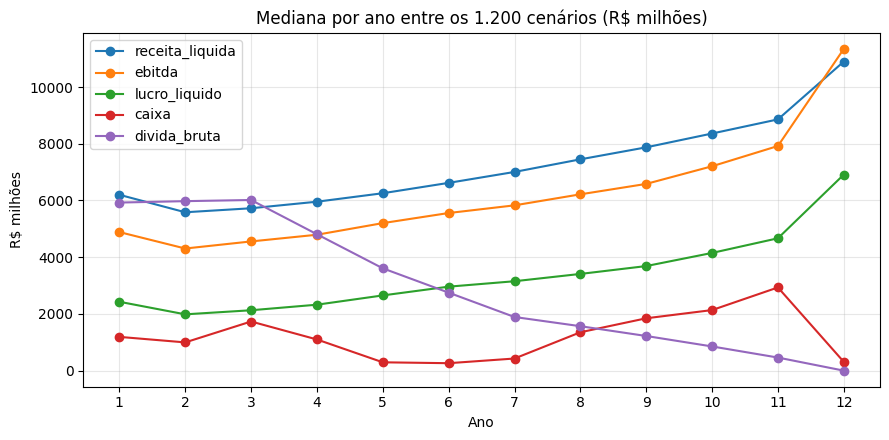

In [12]:
medianas = base_final.groupby('ano')[['receita_liquida', 'ebitda', 'lucro_liquido', 'caixa', 'divida_bruta']].median()
medianas.columns.name = None
medianas.plot(marker='o', figsize=(9, 4.5))
plt.title('Mediana por ano entre os 1.200 cenários (R$ milhões)')
plt.xlabel('Ano'); plt.ylabel('R$ milhões'); plt.xticks(range(1, 13)); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig('evolucao_mediana.png', dpi=150); plt.show()

## Conclusão

A base original (1.002.000 linhas, formato longo) virou uma base analítica com **14.400 linhas (1.200 cenários × 12 anos) e 27 colunas**, sem valores nulos (exceto PL no Ano 12, que não existe) e sem duplicidades. Os demonstrativos batem entre si (saldo do fluxo de caixa = caixa do balanço, ativo = passivo). Essa base alimenta a análise descritiva, os KPIs financeiros e o dashboard da Entrega 02.